In [146]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [147]:
names = open('names.txt', 'r').read().splitlines()

In [148]:
len(names)

32033

In [149]:
chars = sorted(list(set(''.join(names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [150]:
block_size = 3
X,Y=[],[]

for name in names:
    context = [0] * block_size
    for char in name + '.':
        ix = stoi[char]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X = torch.tensor(X)        
Y = torch.tensor(Y)        

print(X.shape)
print(X)

torch.Size([228146, 3])
tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])


In [151]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,100), generator = g)
b1 = torch.randn((100), generator = g)
W2 = torch.randn((100,27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad=True

In [152]:
# #CURRENT CONFIG: whole set of data being used in training the neural network

# for _ in range(100):
#     #FORWARD PASS
#     embed = C[X] #embed values in X to C
#     h = torch.tanh(embed.view(embed.shape[0],6) @ W1 + b1)
#     logits = h @ W2 + b2
#     loss = F.cross_entropy(logits,Y) #essentially the same as getting counts, probs, loss. 
#     # less intermediate tensors, clustering of operations are made for efficiency. both for forward and backward pass.
#     #BACKWARD PASS
#     for p in parameters:
#         p.grad = None
    
#     loss.backward()
#     for p in parameters:
#         p.data += -0.1*p.grad
#     print(loss.item())


In [153]:
lre = torch.linspace(-3,0,1000)
learning_rates = 10**lre

In [154]:
learning_rates[7]

tensor(0.0010)

In [155]:
#CURRENT CONFIG: batch training with variable learning rate
lri = []
loss_i = []
for i in range(1000):

    ix = torch.randint(0,X.shape[0],(32,))
    
    #FORWARD PASS
    embed2 = C[X[ix]] #embed values in X to C
    h2 = torch.tanh(embed2.view(embed.shape[0],6) @ W1 + b1)
    logits2 = h2 @ W2 + b2
    loss2 = F.cross_entropy(logits2,Y[ix]) #essentially the same as getting counts, probs, loss. 
    # less intermediate tensors, clustering of operations are made for efficiency. both for forward and backward pass.
    #BACKWARD PASS
    for p in parameters:
        p.grad = None
    
    loss2.backward()
    learningrate = learning_rates[i]
    lri.append(learningrate)
    for p in parameters:
        p.data += -learningrate*p.grad
    loss_i.append(loss2.item())
    print(loss2.item())

print(loss_i.index(min(loss_i)))



19.871328353881836
18.608537673950195
18.686595916748047
20.285669326782227
22.043975830078125
21.99092674255371
18.803237915039062
17.539337158203125
17.47014617919922
16.96030044555664
15.847966194152832
16.29498291015625
16.43889808654785
17.593446731567383
20.177682876586914
17.15926742553711
18.614593505859375
18.0853328704834
21.393033981323242
18.182321548461914
17.75975227355957
18.969270706176758
19.983869552612305
18.67761993408203
17.901243209838867
16.586795806884766
17.222761154174805
18.66336441040039
21.18100929260254
17.60672378540039
20.156627655029297
17.568687438964844
22.848411560058594
17.113189697265625
16.857126235961914
20.11184310913086
19.20566749572754
18.905662536621094
19.318172454833984
17.705472946166992
15.893999099731445
17.90489959716797
16.63969612121582
18.348264694213867
16.735937118530273
19.285627365112305
17.166561126708984
19.428272247314453
16.007526397705078
16.036170959472656
19.97465705871582
16.857091903686523
19.385087966918945
18.29304504

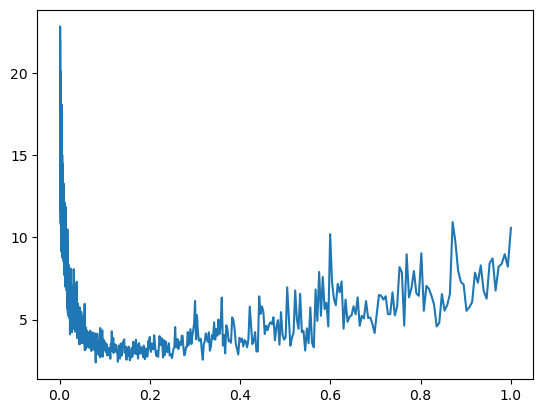

In [156]:
plt.plot(lri,loss_i)